In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 15: 3D Candidate Consolidation with Non-Maximum Suppression

**Objective:** Reduce redundant LoG detections by merging nearby candidates in 3D, then test whether this improves detector precision-like behavior while preserving GT coverage.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- explain why raw LoG produces many redundant candidates
- implement a simple **3D non-maximum suppression (NMS)** / consolidation step
- compare raw LoG vs consolidated LoG on candidate count, GT recall, and precision-like score
- test whether consolidation makes the downstream ranking problem easier
- identify whether NMS improves the quality of the candidate set before machine learning

# 🧠 Background Theory

Chapter 14 showed that the raw LoG detector often places **at least one candidate near a GT cell**, but it also produces **far too many total candidates**.

That suggests a new failure mode:

> A single real nucleus may generate **multiple nearby LoG detections**, often on adjacent z-slices or in the same local neighborhood.

This is a problem because:

- it inflates the number of candidates
- it wastes top-k ranking slots on duplicates
- it makes precision-like scores very low
- it forces the learned ranker to separate “good candidate vs almost-the-same good candidate”

## Goal of this chapter
Before ranking, I want to **consolidate nearby raw LoG detections** so that clusters of redundant candidates become a single representative candidate.

This is a simple form of **3D non-maximum suppression (NMS)**.

If it works, I should get:

- fewer total candidates
- similar GT recall
- better precision-like score
- a cleaner candidate set for later ranking

# 🗺️ Chapter Roadmap

This notebook will proceed in eight stages:

1. **Load the sample and GT nodes**
2. **Run raw LoG detection on one frame**
3. **Define a 3D candidate consolidation / NMS function**
4. **Apply consolidation to the raw LoG candidate set**
5. **Compare raw vs consolidated candidate counts**
6. **Evaluate both candidate sets against GT**
7. **Visualize raw vs consolidated candidates on GT slices**
8. **Interpret whether consolidation helps before ranking**

# 📚 New Vocabulary

## Candidate Consolidation
A process that merges multiple nearby detections into a single representative candidate.

## Non-Maximum Suppression (NMS)
A common detection post-processing step that removes redundant overlapping detections and keeps only the strongest candidate in a local neighborhood.

## Suppression Radius
The 3D distance threshold below which two candidates are considered duplicates.

## Representative Candidate
The one candidate kept from a cluster of nearby detections, usually chosen by some score such as intensity or confidence.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 83.8 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import blob_log

In [4]:
print("Imports successful.")

Imports successful.


# Step 1 — Load the Sample and Ground Truth

I will continue using sample `44b6_12dfb391` so I can compare this chapter directly to the raw LoG and oracle results from Chapters 11–14.

In [5]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

# Load image
volume = zarr.open(zarr_path, mode="r")
image = volume["0"]   # shape: (T, Z, Y, X)

# Load GT nodes
geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

print("Image shape:", image.shape)
print("GT nodes:", len(nodes_df))
nodes_df.head()

Image shape: (100, 64, 256, 256)
GT nodes: 788


,node_id,t,z,y,x
0,106000000037,0,35,61,189
1,106000000040,0,15,194,55
2,106000000041,0,7,239,56
3,106000000043,0,27,211,109
4,106000000056,0,40,127,130


# Step 2 — Choose the Evaluation Timepoint

I will start with timepoint `t = 8` because earlier chapters already used it for detector inspection, GT visualization, and distance-based evaluation.

In [6]:
t = 8

frame_3d = image[t]
gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")

print("Selected timepoint:", t)
print("Frame shape:", frame_3d.shape)
print("Ground-truth nodes at this timepoint:", len(gt_nodes_t))

gt_nodes_t

Selected timepoint: 8
Frame shape: (64, 256, 256)
Ground-truth nodes at this timepoint: 11


,node_id,t,z,y,x
82,114000000041,8,10,237,65
81,114000000040,8,15,184,60
87,114000000080,8,17,248,101
90,114000000084,8,18,2,116
89,114000000082,8,22,199,63
84,114000000043,8,25,208,115
83,114000000042,8,27,156,0
88,114000000081,8,28,122,100
80,114000000037,8,37,50,192
86,114000000063,8,40,198,98


# Step 3 — Define Raw LoG Detection

I will reuse a slice-wise LoG detector that scans each z-slice independently and returns candidate centroids as `(z, y, x)` points.

In [7]:
def detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
):
    detections = []

    for z in range(frame_3d.shape[0]):
        slice_2d = frame_3d[z].astype(np.float32)

        s_min, s_max = slice_2d.min(), slice_2d.max()
        if s_max > s_min:
            slice_norm = (slice_2d - s_min) / (s_max - s_min)
        else:
            slice_norm = slice_2d

        blobs = blob_log(
            slice_norm,
            min_sigma=min_sigma,
            max_sigma=max_sigma,
            num_sigma=num_sigma,
            threshold=threshold
        )

        for blob in blobs:
            y, x, sigma = blob
            detections.append({
                "z": int(z),
                "y": int(round(y)),
                "x": int(round(x)),
                "sigma": float(sigma)
            })

    return pd.DataFrame(detections)

# Step 4 — Run Raw LoG on the Selected Timepoint

In [8]:
raw_pred_df = detect_blobs_log_3d_slicewise(
    frame_3d,
    min_sigma=2.5,
    max_sigma=3.5,
    num_sigma=3,
    threshold=0.15
)

print("Raw LoG candidate count:", len(raw_pred_df))
raw_pred_df.head(10)

Raw LoG candidate count: 1478


,z,y,x,sigma
0,0,92,0,3.5
1,0,183,6,3.5
2,0,118,19,3.5
3,0,212,75,3.5
4,0,208,19,3.5
5,1,93,0,3.5
6,1,118,18,3.5
7,1,93,20,3.5
8,1,239,55,3.5
9,1,141,30,3.5


# Step 5 — Add a Simple Candidate Strength Score

To perform consolidation, I need a way to decide which nearby candidate to keep.

For now, I will use **center intensity** as a simple score:
- higher center intensity = stronger candidate

In [9]:
def add_center_intensity(frame_3d, pred_df):
    pred_df = pred_df.copy()

    intensities = []
    Z, Y, X = frame_3d.shape

    for _, row in pred_df.iterrows():
        z, y, x = int(row["z"]), int(row["y"]), int(row["x"])
        z = np.clip(z, 0, Z - 1)
        y = np.clip(y, 0, Y - 1)
        x = np.clip(x, 0, X - 1)

        intensities.append(float(frame_3d[z, y, x]))

    pred_df["center_intensity"] = intensities
    return pred_df

In [10]:
raw_pred_df = add_center_intensity(frame_3d, raw_pred_df)
raw_pred_df.head(10)

,z,y,x,sigma,center_intensity
0,0,92,0,3.5,1280.0
1,0,183,6,3.5,1250.0
2,0,118,19,3.5,867.0
3,0,212,75,3.5,1028.0
4,0,208,19,3.5,885.0
5,1,93,0,3.5,1504.0
6,1,118,18,3.5,1138.0
7,1,93,20,3.5,921.0
8,1,239,55,3.5,1109.0
9,1,141,30,3.5,951.0


# Step 6 — Define 3D Candidate Consolidation / NMS

I will implement a simple greedy suppression algorithm:

1. sort candidates by `center_intensity` from highest to lowest
2. keep the strongest remaining candidate
3. remove all other candidates within a chosen 3D radius
4. repeat until no candidates remain

This creates a consolidated candidate set where nearby duplicates collapse into one representative point.

In [11]:
def pairwise_distances_3d(gt_points, pred_points):
    gt = gt_points[:, None, :]
    pred = pred_points[None, :, :]
    distances = np.sqrt(((gt - pred) ** 2).sum(axis=2))
    return distances

In [12]:
def consolidate_candidates_3d(pred_df, radius=4.0, score_col="center_intensity"):
    """
    Greedy 3D non-maximum suppression / consolidation.

    Keeps the strongest candidate, then removes all other candidates
    within the given 3D Euclidean radius.
    """
    if len(pred_df) == 0:
        return pred_df.copy()

    work_df = pred_df.copy().sort_values(score_col, ascending=False).reset_index(drop=True)
    kept_rows = []

    while len(work_df) > 0:
        keep = work_df.iloc[0]
        kept_rows.append(keep)

        keep_point = np.array([keep["z"], keep["y"], keep["x"]], dtype=float)
        other_points = work_df[["z", "y", "x"]].to_numpy(dtype=float)

        dists = np.sqrt(((other_points - keep_point) ** 2).sum(axis=1))

        # Keep only candidates outside suppression radius
        work_df = work_df[dists > radius].reset_index(drop=True)

    consolidated_df = pd.DataFrame(kept_rows).reset_index(drop=True)
    return consolidated_df

# Step 7 — Apply Consolidation

I will start with a **3D suppression radius of 4 voxels**.

This is large enough to merge very nearby duplicate candidates, but small enough that distinct nearby nuclei may still survive as separate candidates.

In [13]:
nms_radius = 4.0

nms_pred_df = consolidate_candidates_3d(
    raw_pred_df,
    radius=nms_radius,
    score_col="center_intensity"
)

print("Raw candidate count:", len(raw_pred_df))
print("Consolidated candidate count:", len(nms_pred_df))
print("Candidates removed:", len(raw_pred_df) - len(nms_pred_df))

nms_pred_df.head(10)

Raw candidate count: 1478
Consolidated candidate count: 577
Candidates removed: 901


,z,y,x,sigma,center_intensity
0,58.0,33.0,255.0,3.5,3224.0
1,52.0,35.0,163.0,3.5,3074.0
2,40.0,238.0,101.0,3.5,2960.0
3,37.0,240.0,70.0,3.5,2681.0
4,54.0,164.0,254.0,3.5,2655.0
5,54.0,71.0,204.0,3.5,2567.0
6,18.0,26.0,54.0,3.5,2540.0
7,27.0,61.0,176.0,3.5,2520.0
8,36.0,41.0,47.0,3.5,2478.0
9,42.0,123.0,142.0,3.5,2476.0


# Step 8 — Evaluate Raw and Consolidated Candidate Sets Against GT

I will compare the raw and consolidated candidate sets using the same distance-based evaluation style as earlier chapters.

A GT cell counts as detected if its nearest prediction is within a chosen match radius.

For consistency, I will use:
- **match radius = 5 voxels**

In [14]:
def evaluate_predictions_against_gt(gt_nodes_t, pred_df, match_radius=5):
    gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()

    if len(pred_df) == 0:
        return {
            "num_gt": len(gt_nodes_t),
            "num_pred": 0,
            "gt_detected": 0,
            "gt_missed": len(gt_nodes_t),
            "pred_matched": 0,
            "pred_unmatched": 0,
            "gt_recall": 0.0,
            "pred_precision_like": 0.0,
            "gt_eval_df": gt_nodes_t.assign(
                nearest_pred_dist=np.inf,
                matched=False
            ),
            "pred_eval_df": pred_df.copy()
        }

    pred_points = pred_df[["z", "y", "x"]].to_numpy()

    dist = pairwise_distances_3d(gt_points, pred_points)

    min_dist_gt = dist.min(axis=1)
    min_dist_pred = dist.min(axis=0)

    gt_match_mask = min_dist_gt <= match_radius
    pred_match_mask = min_dist_pred <= match_radius

    gt_eval_df = gt_nodes_t.copy()
    gt_eval_df["nearest_pred_dist"] = min_dist_gt
    gt_eval_df["matched"] = gt_match_mask

    pred_eval_df = pred_df.copy()
    pred_eval_df["nearest_gt_dist"] = min_dist_pred
    pred_eval_df["matched"] = pred_match_mask

    return {
        "num_gt": len(gt_nodes_t),
        "num_pred": len(pred_df),
        "gt_detected": int(gt_match_mask.sum()),
        "gt_missed": int((~gt_match_mask).sum()),
        "pred_matched": int(pred_match_mask.sum()),
        "pred_unmatched": int((~pred_match_mask).sum()),
        "gt_recall": float(gt_match_mask.mean()),
        "pred_precision_like": float(pred_match_mask.mean()),
        "gt_eval_df": gt_eval_df,
        "pred_eval_df": pred_eval_df
    }

In [15]:
match_radius = 5

raw_results = evaluate_predictions_against_gt(
    gt_nodes_t=gt_nodes_t,
    pred_df=raw_pred_df,
    match_radius=match_radius
)

nms_results = evaluate_predictions_against_gt(
    gt_nodes_t=gt_nodes_t,
    pred_df=nms_pred_df,
    match_radius=match_radius
)

# Step 9 — Compare Raw vs Consolidated Metrics

In [16]:
comparison_df = pd.DataFrame([
    {
        "detector": "raw_log",
        "num_gt": raw_results["num_gt"],
        "num_pred": raw_results["num_pred"],
        "gt_detected": raw_results["gt_detected"],
        "gt_missed": raw_results["gt_missed"],
        "pred_matched": raw_results["pred_matched"],
        "pred_unmatched": raw_results["pred_unmatched"],
        "gt_recall": raw_results["gt_recall"],
        "pred_precision_like": raw_results["pred_precision_like"],
    },
    {
        "detector": f"log_plus_nms_r{nms_radius}",
        "num_gt": nms_results["num_gt"],
        "num_pred": nms_results["num_pred"],
        "gt_detected": nms_results["gt_detected"],
        "gt_missed": nms_results["gt_missed"],
        "pred_matched": nms_results["pred_matched"],
        "pred_unmatched": nms_results["pred_unmatched"],
        "gt_recall": nms_results["gt_recall"],
        "pred_precision_like": nms_results["pred_precision_like"],
    }
])

comparison_df

,detector,num_gt,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like
0,raw_log,11,1478,8,3,21,1457,0.727273,0.014208
1,log_plus_nms_r4.0,11,577,7,4,8,569,0.636364,0.013865


# Step 10 — Quantify the Effect of Consolidation

I want to measure whether consolidation:

- removes many candidates
- preserves GT recall
- improves precision-like behavior

In [17]:
reduction_summary = pd.Series({
    "raw_candidates": len(raw_pred_df),
    "nms_candidates": len(nms_pred_df),
    "removed_candidates": len(raw_pred_df) - len(nms_pred_df),
    "fraction_removed": (len(raw_pred_df) - len(nms_pred_df)) / len(raw_pred_df) if len(raw_pred_df) > 0 else np.nan,
    "raw_gt_recall": raw_results["gt_recall"],
    "nms_gt_recall": nms_results["gt_recall"],
    "raw_precision_like": raw_results["pred_precision_like"],
    "nms_precision_like": nms_results["pred_precision_like"],
})

reduction_summary

raw_candidates        1478.000000
nms_candidates         577.000000
removed_candidates     901.000000
fraction_removed         0.609608
raw_gt_recall            0.727273
nms_gt_recall            0.636364
raw_precision_like       0.014208
nms_precision_like       0.013865
dtype: float64

# Step 11 — Visualize GT Slice Overlays for Raw vs Consolidated Candidates

I will compare the raw and consolidated candidates on the GT slices for this timepoint.

Legend:
- **red circles** = GT centroids
- **cyan x** = raw LoG candidates
- **lime +** = consolidated NMS candidates

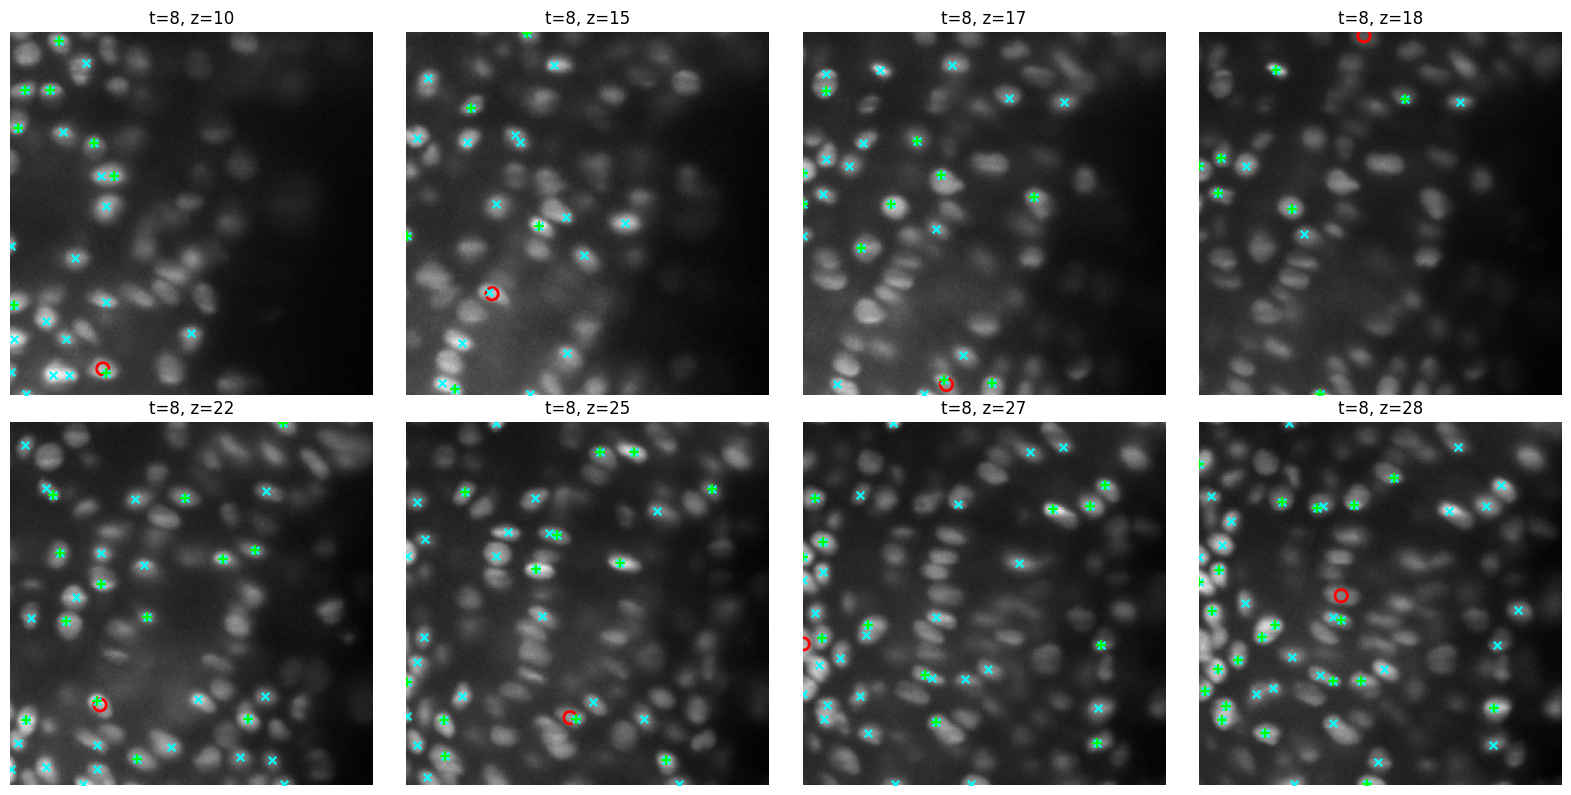

In [18]:
z_slices = sorted(gt_nodes_t["z"].unique())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, z in zip(axes, z_slices[:8]):
    slice_img = frame_3d[z]

    gt_slice = gt_nodes_t[gt_nodes_t["z"] == z]
    raw_slice = raw_pred_df[raw_pred_df["z"] == z]
    nms_slice = nms_pred_df[nms_pred_df["z"] == z]

    ax.imshow(slice_img, cmap="gray")

    # GT
    ax.scatter(
        gt_slice["x"], gt_slice["y"],
        facecolors="none",
        edgecolors="red",
        s=80,
        linewidths=2
    )

    # Raw predictions
    ax.scatter(
        raw_slice["x"], raw_slice["y"],
        c="cyan",
        marker="x",
        s=30
    )

    # Consolidated predictions
    ax.scatter(
        nms_slice["x"], nms_slice["y"],
        c="lime",
        marker="+",
        s=60
    )

    ax.set_title(f"t={t}, z={z}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Step 12 — Inspect Which GT Cells Are Lost After Consolidation

If NMS is too aggressive, it may remove candidates needed to cover a GT cell.

This table helps identify GT cells that were detected by raw LoG but missed after consolidation.

In [19]:
raw_gt_eval = raw_results["gt_eval_df"].copy()
nms_gt_eval = nms_results["gt_eval_df"].copy()

gt_compare_df = gt_nodes_t[["node_id", "z", "y", "x"]].copy()
gt_compare_df["raw_nearest_dist"] = raw_gt_eval["nearest_pred_dist"].values
gt_compare_df["raw_matched"] = raw_gt_eval["matched"].values
gt_compare_df["nms_nearest_dist"] = nms_gt_eval["nearest_pred_dist"].values
gt_compare_df["nms_matched"] = nms_gt_eval["matched"].values

gt_compare_df["lost_after_nms"] = gt_compare_df["raw_matched"] & (~gt_compare_df["nms_matched"])
gt_compare_df["newly_matched_after_nms"] = (~gt_compare_df["raw_matched"]) & gt_compare_df["nms_matched"]

gt_compare_df.sort_values(["lost_after_nms", "nms_nearest_dist"], ascending=[False, False])

,node_id,z,y,x,raw_nearest_dist,raw_matched,nms_nearest_dist,nms_matched,lost_after_nms,newly_matched_after_nms
85,114000000056,42,118,138,4.242641,True,6.403124,False,True,False
90,114000000084,18,2,116,14.456832,False,14.456832,False,False,False
83,114000000042,27,156,0,13.038405,False,13.601471,False,False,False
88,114000000081,28,122,100,7.071068,False,8.124038,False,False,False
84,114000000043,25,208,115,3.316625,True,4.123106,True,False,False
82,114000000041,10,237,65,1.732051,True,3.605551,True,False,False
87,114000000080,17,248,101,3.605551,True,3.605551,True,False,False
89,114000000082,22,199,63,2.236068,True,3.605551,True,False,False
81,114000000040,15,184,60,2.236068,True,3.316625,True,False,False
80,114000000037,37,50,192,3.316625,True,3.316625,True,False,False


# Step 13 — Test Multiple Suppression Radii

A single NMS radius may not be ideal, so I will compare several radii:

- 2 voxels
- 3 voxels
- 4 voxels
- 5 voxels
- 6 voxels

This will show the tradeoff between:
- removing duplicates
- preserving GT coverage

In [20]:
radius_grid = [2, 3, 4, 5, 6]

radius_results = []

for r in radius_grid:
    nms_df_r = consolidate_candidates_3d(
        raw_pred_df,
        radius=float(r),
        score_col="center_intensity"
    )

    eval_r = evaluate_predictions_against_gt(
        gt_nodes_t=gt_nodes_t,
        pred_df=nms_df_r,
        match_radius=match_radius
    )

    radius_results.append({
        "nms_radius": r,
        "num_pred": eval_r["num_pred"],
        "gt_detected": eval_r["gt_detected"],
        "gt_missed": eval_r["gt_missed"],
        "pred_matched": eval_r["pred_matched"],
        "pred_unmatched": eval_r["pred_unmatched"],
        "gt_recall": eval_r["gt_recall"],
        "pred_precision_like": eval_r["pred_precision_like"],
    })

radius_results_df = pd.DataFrame(radius_results)
radius_results_df

,nms_radius,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like
0,2,862,8,3,15,847,0.727273,0.017401
1,3,661,8,3,10,651,0.727273,0.015129
2,4,577,7,4,8,569,0.636364,0.013865
3,5,515,7,4,8,507,0.636364,0.015534
4,6,478,7,4,8,470,0.636364,0.016736


# Step 14 — Plot Candidate Count vs NMS Radius

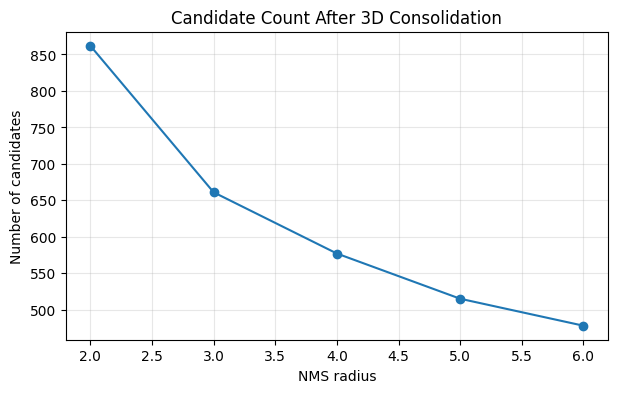

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(radius_results_df["nms_radius"], radius_results_df["num_pred"], marker="o")
plt.title("Candidate Count After 3D Consolidation")
plt.xlabel("NMS radius")
plt.ylabel("Number of candidates")
plt.grid(True, alpha=0.3)
plt.show()

# Step 15 — Plot GT Recall and Precision-like vs NMS Radius

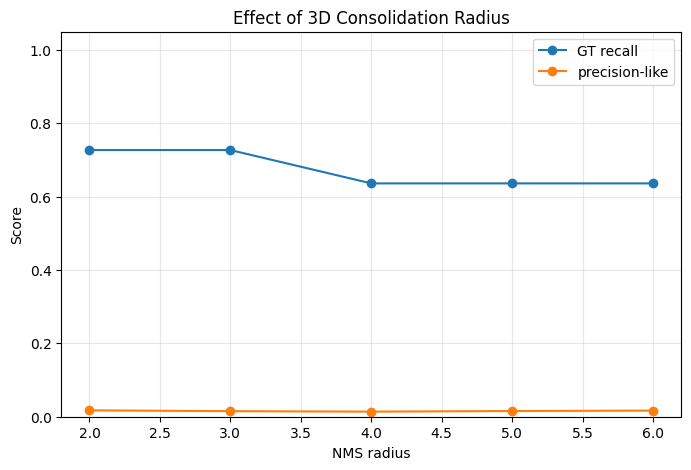

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(radius_results_df["nms_radius"], radius_results_df["gt_recall"], marker="o", label="GT recall")
plt.plot(radius_results_df["nms_radius"], radius_results_df["pred_precision_like"], marker="o", label="precision-like")
plt.title("Effect of 3D Consolidation Radius")
plt.xlabel("NMS radius")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Step 16 — Find the Best NMS Radius for This Timepoint

For now, I will define “best” as:

1. preserve GT recall as much as possible
2. among similar recall values, prefer higher precision-like
3. also prefer fewer candidates

In [23]:
radius_results_df.sort_values(
    ["gt_recall", "pred_precision_like", "num_pred"],
    ascending=[False, False, True]
)

,nms_radius,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like
0,2,862,8,3,15,847,0.727273,0.017401
1,3,661,8,3,10,651,0.727273,0.015129
4,6,478,7,4,8,470,0.636364,0.016736
3,5,515,7,4,8,507,0.636364,0.015534
2,4,577,7,4,8,569,0.636364,0.013865


# 📊 Results

3D candidate consolidation reduced the raw LoG candidate set substantially.

## Raw LoG
- candidates: 1478
- GT detected: 8 / 11
- GT recall: 0.727
- precision-like: 0.0142

## NMS radius 4
- candidates: 577
- candidates removed: 901
- fraction removed: 0.6096
- GT detected: 7 / 11
- GT recall: 0.636
- precision-like: 0.0139

## NMS radius sweep
The best practical setting was radius 3:

- candidates: 661
- GT detected: 8 / 11
- GT recall: 0.727
- precision-like: 0.0151

Radius 3 preserved raw LoG recall while reducing the candidate pool by more than half.

# 🔍 Analysis

3D NMS helped reduce redundant LoG candidates, but it did not meaningfully improve precision-like behavior by itself.

The key tradeoff was:

- small NMS radius preserved GT coverage
- larger NMS radius removed more candidates but began losing GT detections

Radius 3 appears to be the best compromise for this frame. It reduced the candidate count from 1478 to 661 while preserving 8 / 11 detected GT cells.

This suggests that consolidation is useful as a preprocessing step, but it is not sufficient as a final detector.

# 📝 What I Learned

Today I learned that:

- raw LoG contains many redundant nearby detections
- 3D NMS can remove many duplicates
- too much suppression can remove candidates needed to cover GT cells
- NMS radius 3 is a promising starting point
- consolidation should happen before ranking, not replace ranking